<a href="https://colab.research.google.com/github/soumensen411/Deep-Learning-Model/blob/main/CNN/CIFAR10_project/CIFAR10_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import Dense,Conv2D,MaxPooling2D
from keras.layers import Dropout,Flatten,BatchNormalization
from keras.optimizers import Adam

In [44]:
df = cifar10.load_data()

In [45]:
(X_train, y_train), (X_test, y_test) = df


In [46]:
X_train, X_valid, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [47]:
X_train.shape

(45000, 32, 32, 3)

In [48]:
y_train.shape

(45000, 1)

In [49]:
X_valid.shape,y_validation.shape

((5000, 32, 32, 3), (5000, 1))

In [50]:
X_test.shape,y_test.shape

((10000, 32, 32, 3), (10000, 1))

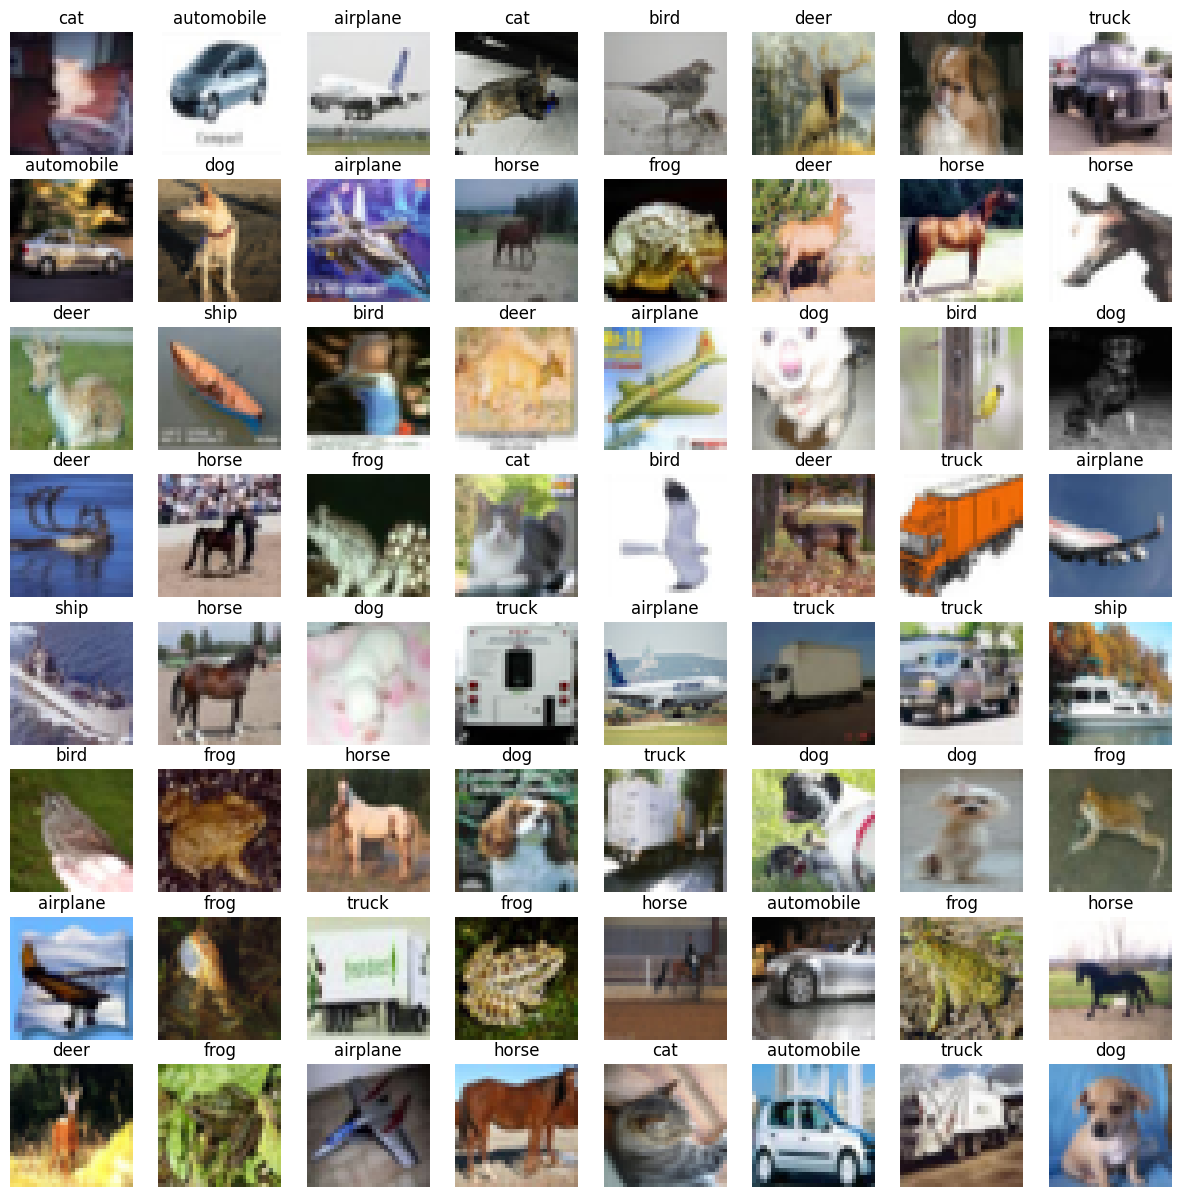

In [51]:
class_name = [
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]
plt.figure(figsize=(15,15))
for i in range(64):
  plt.subplot(8,8,i+1)
  plt.imshow(X_train[i])
  plt.xticks([])
  plt.yticks([])
  plt.title(class_name[y_train[i][0]])
  plt.axis('off')

# Data Preprocessing

Normalize the data

In [52]:
X_train =  X_train.astype('float32')
X_test = X_test.astype('float32')
X_valid = X_valid.astype('float32')

mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train-mean)/(std+0.000001)
X_test = (X_test-mean)/(std+0.000001)
X_valid = (X_valid-mean)/(std+0.000001)

One hot encoding

In [53]:
y_train = to_categorical(y_train.flatten(), 10)
y_test = to_categorical(y_test.flatten(), 10)
y_validation = to_categorical(y_validation.flatten(), 10)

# Data Augmentation

In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
image_augmentation = ImageDataGenerator(
    rotation_range= 15,
    width_shift_range = 0.12,
    height_shift_range = 0.12,
    zoom_range = 0.1,
    horizontal_flip = True,
    brightness_range = [0.9,1.1],
    shear_range = 10,
    channel_shift_range = 0.1

)

# Model

In [55]:
import tensorflow.keras.regularizers as regularizers

weightDecay = 0.0001
model = Sequential([
    Conv2D(filters=32,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer=regularizers.l2(weightDecay) ,input_shape=(X_train.shape[1:])),
    BatchNormalization(),

    Conv2D(filters=32,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    Conv2D(filters=64,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    Conv2D(filters=64,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),

    Conv2D(filters=128,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    Conv2D(filters=128,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    Conv2D(filters=256,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    Conv2D(filters=256,kernel_size = (3,3),activation='relu',padding='same',kernel_regularizer = regularizers.l2(weightDecay)),
    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.5),

    Flatten(),

    Dense(10,activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,186,346 (4.53 MB)

 Trainable params: 1,184,426 (4.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [57]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

model.compile(optimizer = 'adam',loss='categorical_crossentropy',metrics = ['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',factor = 0.5,patience = 10,min_lr = 0.00001)
earlyStop = EarlyStopping(monitor = 'val_loss',patience = 40,verbose = 1,restore_best_weights = True)

history = model.fit(image_augmentation.flow(X_train,y_train,batch_size = 64),
          epochs = 10,
          validation_data=(X_valid, y_validation),
          callbacks=[reduce_lr,earlyStop],
          verbose = 2)

Epoch 1/10
704/704 - 78s - 111ms/step - accuracy: 0.3618 - loss: 2.2099 - val_accuracy: 0.4690 - val_loss: 1.7048 - learning_rate: 0.0010
Epoch 2/10
704/704 - 50s - 71ms/step - accuracy: 0.4986 - loss: 1.6753 - val_accuracy: 0.5246 - val_loss: 1.5872 - learning_rate: 0.0010
Epoch 3/10
704/704 - 50s - 71ms/step - accuracy: 0.5663 - loss: 1.4450 - val_accuracy: 0.6306 - val_loss: 1.1596 - learning_rate: 0.0010
Epoch 4/10
704/704 - 49s - 70ms/step - accuracy: 0.6039 - loss: 1.3182 - val_accuracy: 0.6250 - val_loss: 1.2373 - learning_rate: 0.0010
Epoch 5/10
704/704 - 49s - 69ms/step - accuracy: 0.6471 - loss: 1.1849 - val_accuracy: 0.6994 - val_loss: 1.0226 - learning_rate: 0.0010
Epoch 6/10
704/704 - 50s - 71ms/step - accuracy: 0.6747 - loss: 1.1181 - val_accuracy: 0.6652 - val_loss: 1.1609 - learning_rate: 0.0010
Epoch 7/10
704/704 - 50s - 71ms/step - accuracy: 0.6934 - loss: 1.0889 - val_accuracy: 0.7398 - val_loss: 0.9230 - learning_rate: 0.0010
Epoch 8/10
704/704 - 50s - 71ms/step - a

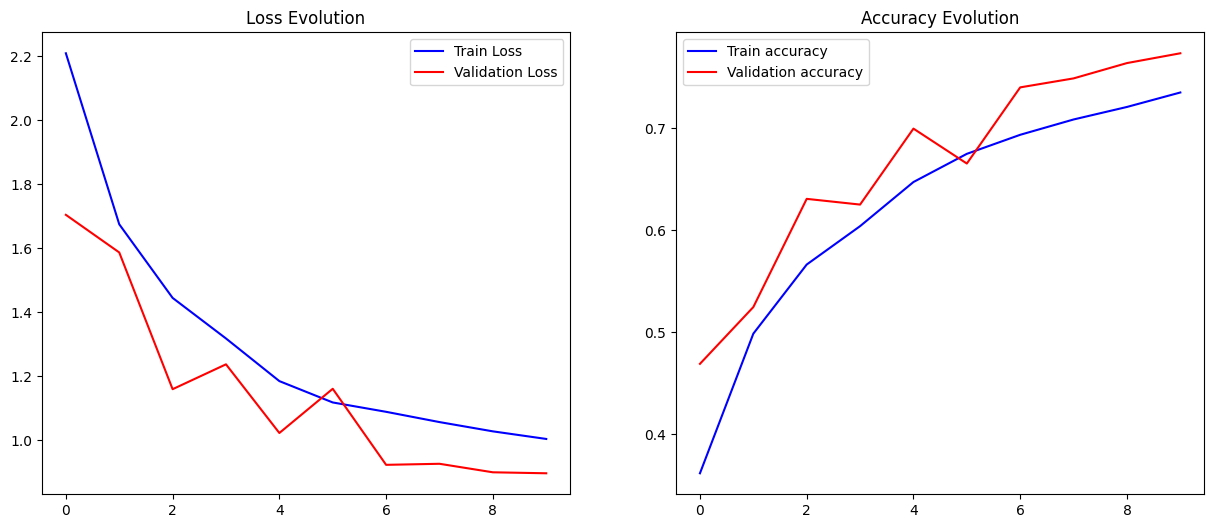

In [61]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label = 'Train Loss', color = 'blue')
plt.plot(model.history.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label = 'Train accuracy', color = 'blue')
plt.plot(model.history.history['val_accuracy'], label = 'Validation accuracy', color = 'red')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

In [62]:
test_loss, test_acc = model.evaluate(X_test,y_test, verbose = 1)
print(f'Test Accuracy : {test_acc}\nTestLoss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7656 - loss: 0.9238
Test Accuracy : 0.7656000256538391
TestLoss: 0.923818826675415


In [71]:
import urllib.request

url = 'https://rightforeducation.org/wp-content/uploads/2026/02/52-e1770295315617.jpg'
# 'https://naturealberta.ca/wp-content/uploads/2025/04/6.-Tree-Swallow-NICK-CARTER-1536x1340.jpg'
#'https://wildjolie.com/cdn/shop/articles/Do_Horses_Have_Horns.jpg?v=1741247407&width=1780'
reps = urllib.request.urlopen(url)
image = np.asarray(bytearray(reps.read()),dtype='uint8')
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image from bgr to rgb

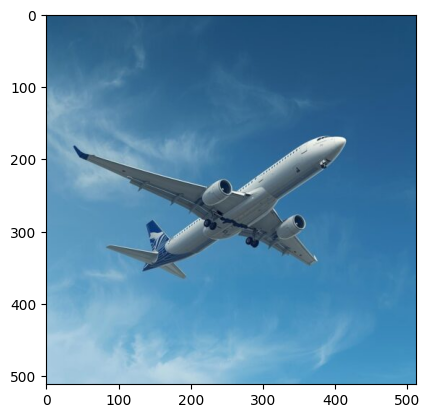

In [72]:
plt.imshow(image)

In [73]:
image.shape

(512, 512, 3)

In [74]:
image = cv2.resize(image, (32,32))
image = (image-mean)/(std+0.000001)
image = image.reshape((1,32,32,3))

In [75]:

predict = model.predict(image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [76]:
print(f'The predicted class: {class_name[predict.argmax()]}')

The predicted class: airplane
